Python Notebook to implement MASC algorithm on Indian Pines dataset.

# Import Packages

In [5]:
import numpy as np
import random
import pandas as pd
from scipy import stats
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.special import jacobi
import copy
from sklearn import metrics
import csv

import scipy.io

# Import and Setup Data

In [6]:
mat_data = scipy.io.loadmat('Indian_pines_corrected.mat')
data = mat_data["indian_pines_corrected"]
x, y, z = data.shape
indian_pines = data.reshape((x*y, z))
norms = np.linalg.norm(indian_pines, axis=1)
indian_pines = indian_pines / norms[:, np.newaxis]
mat_data_gt = scipy.io.loadmat('Indian_pines_gt.mat')
gt = mat_data_gt["indian_pines_gt"]
gt = gt.reshape(-1)

In [7]:
mask = np.isin(gt, [2, 6, 11,14,16])

train=indian_pines[mask]
target=gt[mask]

In [8]:
trainsize=len(train[:,0])
classes=np.sort(list(dict.fromkeys(target)))
print(f"Vector of class labels: {classes}")
for i in classes:
    print(f"Number of points in class {i}: {len(np.where(target==i)[0])}")

Vector of class labels: [ 2  6 11 14 16]
Number of points in class 2: 1428
Number of points in class 6: 730
Number of points in class 11: 2455
Number of points in class 14: 1265
Number of points in class 16: 93


Define Data matrices on the sphere.

1.0 -0.09270159335301253
1.6636312094154018 0.0


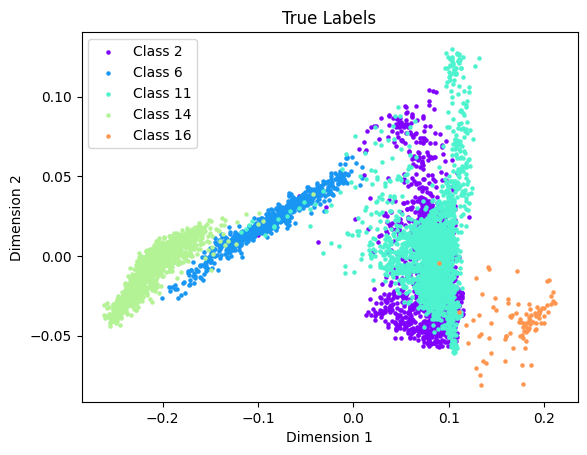

In [9]:
#Translate Training Data to have range centered at zero
avg=(np.max(train, axis=0)+np.min(train, axis=0))/2
traincen=train-avg

#Project Data to the sphere with hyperparameter alpha in (0,2]
alpha=1
maxnorm=np.max(np.linalg.norm(traincen, axis=1))
scaledtrain=alpha*traincen/maxnorm #alpha can be changed to any value <=2 to control spread of data
r=np.linalg.norm(scaledtrain, axis=1)
trainsph=np.hstack((((4*(scaledtrain.T*r).T).T/((4+r**2)*r)).T,((4-r**2)/(4+r**2)).reshape(trainsize,1)))
normsph=np.linalg.norm(trainsph, axis=1)

#Matrix of angles between points
sphmat=np.matmul(trainsph,np.transpose(trainsph))
#this line is for slight rounding error causing out-of-bounds for arccos
sphmat[sphmat>1]=1

#Matrix of spherical distance between points
distmat=np.arccos(sphmat)
print(sphmat.max(),sphmat.min())
print(distmat.max(),distmat.min())

#Visualize data using first 2 dimensions of SVD
mean=np.mean(train,axis=0)
centeredtrain=train-mean
uu, ss, vv=np.linalg.svd(centeredtrain)
plotdim1=np.matmul(np.asarray(centeredtrain),vv[0])
plotdim2=np.matmul(np.asarray(centeredtrain),vv[1])
c=cm.rainbow(np.linspace(0,1,len(classes)+1))
color=0
for i in classes:
    plt.scatter(plotdim1[np.where(target==i)[0]],plotdim2[np.where(target==i)[0]],s=5,color=c[color],label=f"Class {i}")
    color+=1
plt.title('True Labels')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

# Show the plot
plt.show()

# Define Localized Kernels

Positive Chebyshev Kernel for use with support estimation. Included is a piecewise linear estimation of the kernel for improved run-times.

In [10]:
#defining the half-pass filter
def h(t):
    t = np.abs(t)
    out = np.zeros_like(t)
    for i in range(len(t)):
        if t[i] <= 1/2:
            out[i] = 1
        elif (1/2 < np.abs(t[i])) and (np.abs(t[i]) < 1):
            out[i] = np.exp(-np.exp(2/(1-2*t[i]))/(1-t[i]))
        else:
            out[i] = 0
    return out

#Phi Kernel Definition with degree n and input x
def Phi(n,x):
    out=1/(2*np.pi)
    for k in np.arange(1,n,1):
        out+=h([k/n])*np.cos(k*np.arccos(x))/np.pi
    out=out**2
    return out

#Linear interpolation of kernel with greater density of interpolation points near 0. Degree: n, input: x, number of interpolation points: numinterp.
def Phiapprox(n,x,numinterp):
    xdir=x.shape[0]
    if x.ndim==1:
        ydir=1
    if x.ndim==2:
        ydir=x.shape[1]
    xlist=np.vstack((x.reshape(1,xdir*ydir),np.arange(xdir*ydir)))
    phivals=1-2*(1/2-np.linspace(-1,1,numinterp)/2)**(n/2)
    phivec=Phi(n,phivals)
    newmat=np.zeros((xdir*ydir,1))
    for i in np.arange(1,numinterp,1):
        ind=xlist[0]<=phivals[i]
        newmat[xlist[1][ind].astype(int)]=(phivec[i-1]+(xlist[0][ind]-phivals[i-1])*(phivec[i]-phivec[i-1])/(phivals[i]-phivals[i-1])).reshape(ind.sum(),1)
        xlist=np.delete(xlist, ind, 1)
    newmat=np.reshape(newmat,(xdir,ydir))
    return newmat

# MASC Algorithm

Generate Phimat matrix for thresholding and querying.

In [11]:
n=128

#Phi function
Phimat=Phiapprox(n,sphmat,100)
Phisum=np.sum(Phimat,axis=0)

Theta thresholding.

In [12]:
Theta=1

#percentage of data to be captured
datathreshold=.9
verticescount=0

while verticescount<datathreshold*trainsize:
    Theta=Theta-.005
    vertex_list=np.where(Phisum>Theta*Phisum.max())[0]
    verticescount=len(vertex_list)

#distmat for only those points
distmat_sheared=(distmat[vertex_list].T[vertex_list]).T
print(Theta,verticescount)

0.0949999999999992 5461


This cell gives the number of clusters of size p from the thresholded data set for a fixed eta value. Use of this cell is to determine good lower and upper limits for the eta loop in the next cell.

In [13]:
eta=.03

#Adjacency matrix for sheared points
adjmat=np.zeros([verticescount, verticescount])
adjmat[distmat_sheared<eta]=1
adjmat=adjmat-np.identity(len(vertex_list))

#Compute Graph components
graph=csr_matrix(adjmat)
num_components, componentlist = connected_components(csgraph=graph, directed=False, return_labels=True)

#Trim components. Any components of size smaller than this value will be removed from list by setting their component to -1
componentthreshold=5
componentnum, componentsizes=np.unique(componentlist, return_counts="True")
bigcomponents=np.where(componentsizes>componentthreshold)[0]
sheared_componentlist=componentlist[np.isin(componentlist,bigcomponents)]
sheared_componentnum, sheared_componentsizes=np.unique(sheared_componentlist, return_counts="True")

print("Number of points in each component:",sheared_componentsizes,"\n Number of clusters:",np.size(sheared_componentsizes))

Number of points in each component: [ 12  15 180  10   7  17  11  19  16  14   6   7] 
 Number of clusters: 12


Eta for loop of MASC algorithm, with KNN extension calculated for several values in order to show accuracy/#queries information for purposes of plots in the paper. Run time can be improved by only running KNN extension once after the eta loop is done.

In [14]:
predict_labels=np.zeros(trainsize)
A=[]
B=[]
indlist=[]

querycount=0
numqueries=[]
etatrack=[]
MASClist=[]

def Knearest(X,label,K):
    indmat=np.argpartition(-X, K, axis=0)[:K]
    labelsmasked=label[indmat]
    return scipy.stats.mode(labelsmasked, keepdims=True)[0], indmat

for eta in np.arange(.03,.13,.005):
    #Adjacency matrix for sheared points
    adjmat=np.zeros([verticescount, verticescount])
    adjmat[distmat_sheared<eta]=1
    adjmat=adjmat-np.identity(len(vertex_list))

    #Compute Graph components
    graph=csr_matrix(adjmat)
    num_components, componentlist = connected_components(csgraph=graph, directed=False, return_labels=True)

    #Trim components. Any components of size smaller than this value will be removed from list by setting their component to -1
    componentthreshold=5
    componentnum, componentsizes=np.unique(componentlist, return_counts="True")
    bigcomponents=np.where(componentsizes>componentthreshold)[0]
    sheared_componentlist=componentlist[np.isin(componentlist,bigcomponents)]
    sheared_componentnum, sheared_componentsizes=np.unique(sheared_componentlist, return_counts="True")

    #Find modal points in each cluster to query true class label. keep track of x_i and y_i from each.
    for i in sheared_componentnum:
        componentset=vertex_list[np.where(componentlist==i)[0]]
        if np.intersect1d(A,componentset).size==0:

            x_i=componentset[np.argmax(Phisum[componentset])]
            y_i=target[x_i]
            A.append(x_i)
            B.append(y_i)
            predict_labels[componentset]=y_i
            
        elif np.size(np.unique(np.intersect1d(A,componentset)))==1:
            predict_labels[componentset]=target[np.unique(np.intersect1d(A,componentset))[0]]

    if len(A)>querycount+5:
        querycount=len(A)
        labels=copy.deepcopy(predict_labels)
        predict_labels_ind=np.where(predict_labels)[0]
        indlist.append(predict_labels_ind)
        extensionmat=sphmat[predict_labels_ind,:]
        extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
        newlabels,indmat=Knearest(extensionmat,labels[predict_labels_ind],25)
        labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

        truthcheck3=target==labels
        correctnum3=len(np.where(truthcheck3)[0])
        print(f"Number of correctly classified points and queries: {correctnum3} ({100*correctnum3/trainsize:.2f}%), {len(A)}")
        MASClist.append(correctnum3/trainsize)
        numqueries.append(len(A))
        etatrack.append(eta)
            



predict_labels_ind=np.where(predict_labels)[0]
truthcheck=target[predict_labels_ind].T==predict_labels[predict_labels_ind]

print(f"List of classes in the prediction: {np.setdiff1d(list(dict.fromkeys(predict_labels)),[0])}")
print(f"Number of points queried: {len(A)}")
predict_labels_ind=np.where(predict_labels)[0]
truthcheck=target[predict_labels_ind]==predict_labels[predict_labels_ind]
correctnum=len(np.where(truthcheck)[0])
totalnum=len(predict_labels_ind)
print(f"Number of points classified before KNN extension: {totalnum}")
print(f"Number of correctly classified points of those classified before KNN extension: {correctnum} ({100*correctnum/totalnum:.2f}%)")

labels=copy.deepcopy(predict_labels)
predict_labels_ind=np.where(predict_labels)[0]
extensionmat=sphmat[predict_labels_ind,:]
extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
newlabels,indmat=Knearest(extensionmat,labels[predict_labels_ind],15)
labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

truthcheck3=target==labels
correctnum3=len(np.where(truthcheck3)[0])
print(f"Number of correctly classified points and queries: {correctnum3} ({100*correctnum3/trainsize:.2f}%), {len(A)}")
MASClist.append(correctnum3/trainsize)
numqueries.append(len(A))
etatrack.append(eta)

Number of correctly classified points and queries: 3723 (62.35%), 12
Number of correctly classified points and queries: 4813 (80.61%), 55
Number of correctly classified points and queries: 4895 (81.98%), 99
Number of correctly classified points and queries: 4966 (83.17%), 134
Number of correctly classified points and queries: 5009 (83.89%), 152
Number of correctly classified points and queries: 5014 (83.97%), 170
Number of correctly classified points and queries: 5001 (83.75%), 182
Number of correctly classified points and queries: 5019 (84.06%), 190
Number of correctly classified points and queries: 5019 (84.06%), 196
List of classes in the prediction: [ 2.  6. 11. 14. 16.]
Number of points queried: 199
Number of points classified before KNN extension: 3123
Number of correctly classified points of those classified before KNN extension: 2787 (89.24%)
Number of correctly classified points and queries: 5039 (84.39%), 199


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ryanm\AppData\Local\Temp\ipykernel_127276\1680950504.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.scatter(plotdim1[indlist[len(indlist)-i-1]],plotdim2[indlist[len(indlist)-i-1]],s=10,color=c2[i],label=f"Iter. {len(indlist)-i} (#Queries: {numqueries[len(indlist)-i-1]}, $\eta$: {etatrack[len(indlist)-i-1]:.3f})")


(-0.3, 0.5)

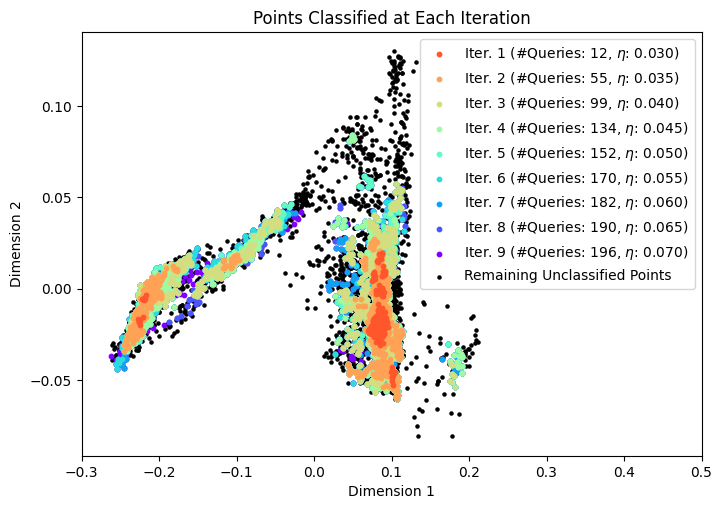

In [15]:
f = plt.figure()
f.set_figwidth(8)
f.set_figheight(5.5)
c2=cm.rainbow(np.linspace(0,1,len(indlist)+1))
plt.scatter(plotdim1,plotdim2,s=5,color='black',label="Remaining Unclassified Points")
for i in range(len(indlist)):
    plt.scatter(plotdim1[indlist[len(indlist)-i-1]],plotdim2[indlist[len(indlist)-i-1]],s=10,color=c2[i],label=f"Iter. {len(indlist)-i} (#Queries: {numqueries[len(indlist)-i-1]}, $\eta$: {etatrack[len(indlist)-i-1]:.3f})")

plt.title('Points Classified at Each Iteration')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.xlim([-.3,.5])

In [16]:
print(numqueries)
print(MASClist)

[12, 55, 99, 134, 152, 170, 182, 190, 196, 199]
[0.623513649304974, 0.8060626360743594, 0.819795679115726, 0.8316864846759336, 0.8388879584659186, 0.8397253391391727, 0.8375481493887121, 0.8405627198124267, 0.8405627198124267, 0.8439122425054429]


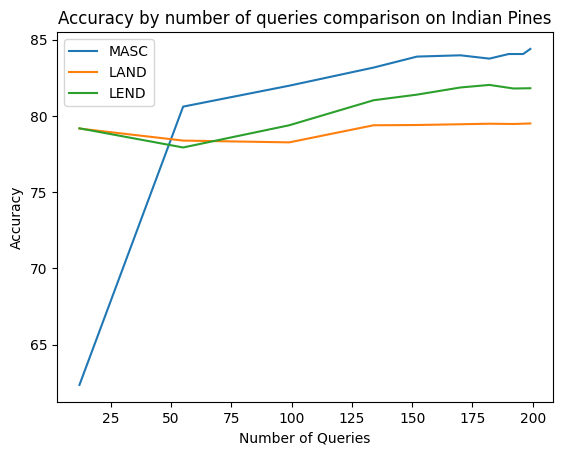

In [17]:
plt.plot(numqueries,[i*100 for i in MASClist],label="MASC")
plt.title('Accuracy by number of queries comparison on Indian Pines')
plt.xlabel('Number of Queries')
plt.ylabel('Accuracy')

# Values from LAND/LEND notebooks
landlendqueries=[12, 55, 99, 134, 152, 170, 182, 192, 199]
landlist=[0.7916596884943896, 0.7837883101658014, 0.7826159772232457, 0.7938368782448502, 0.7940043543795009, 0.7945067827834533, 0.794841735052755, 0.7946742589181042, 0.7950092111874059]
lendlist=[0.7918271646290403, 0.7792664545302295, 0.7938368782448502, 0.8102495394406297, 0.8139340144029475, 0.8186233461731703, 0.8202981075196785, 0.8179534416345671, 0.8181209177692179]
plt.plot(landlendqueries,[i*100 for i in landlist],label="LAND")
plt.plot(landlendqueries,[i*100 for i in lendlist],label="LEND")
plt.legend()

Plot output from MASC algorithm before KNN extension.

2848


<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ryanm\AppData\Local\Temp\ipykernel_127276\1050641518.py:7: SyntaxWarning: invalid escape sequence '\T'
  plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.03,0.13]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')
C:\Users\ryanm\AppData\Local\Temp\ipykernel_127276\1050641518.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.03,0.13]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')


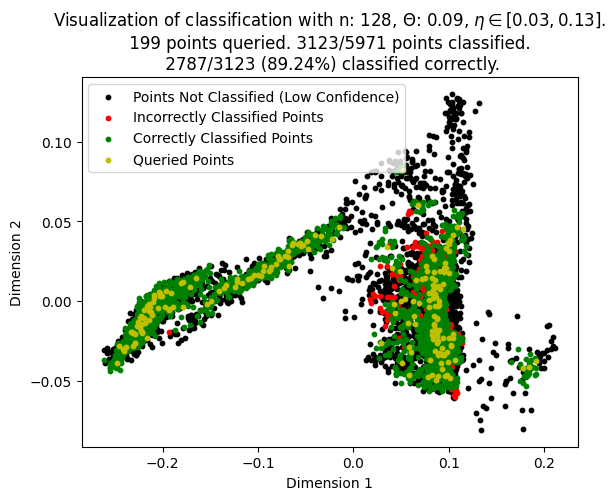

In [18]:
falsepoints=predict_labels_ind[np.where(truthcheck==False)[0]]
truepoints=predict_labels_ind[np.where(truthcheck)[0]]
plt.scatter(plotdim1[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)],plotdim2[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)],s=10,color="black", label=f"Points Not Classified (Low Confidence)")
plt.scatter(plotdim1[falsepoints],plotdim2[falsepoints],s=10,color="r",label=f"Incorrectly Classified Points")
plt.scatter(plotdim1[np.setdiff1d(truepoints,A)],plotdim2[np.setdiff1d(truepoints,A)],color="g",s=10,label=f"Correctly Classified Points")
plt.scatter(plotdim1[A],plotdim2[A],color="y",s=10,label=f"Queried Points")
plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.03,0.13]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

print(len(np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)))
plt.show()

# KNN Extension

Currently this cell is already included in the eta loop cell above.

In [19]:
labels=copy.deepcopy(predict_labels)

def Knearest(X,label,K):
    indmat=np.argpartition(-X, K, axis=0)[:K]
    labelsmasked=label[indmat]
    return scipy.stats.mode(labelsmasked, keepdims=True)[0], indmat

extensionmat=sphmat[predict_labels_ind,:]
extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
newlabels,indmat=Knearest(extensionmat,labels[predict_labels_ind],15)
labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

truthcheck3=target==labels
correctnum3=len(np.where(truthcheck3)[0])
print(f"Number of correctly classified points: {correctnum3} ({100*correctnum3/trainsize:.2f}%)")


Number of correctly classified points: 5039 (84.39%)


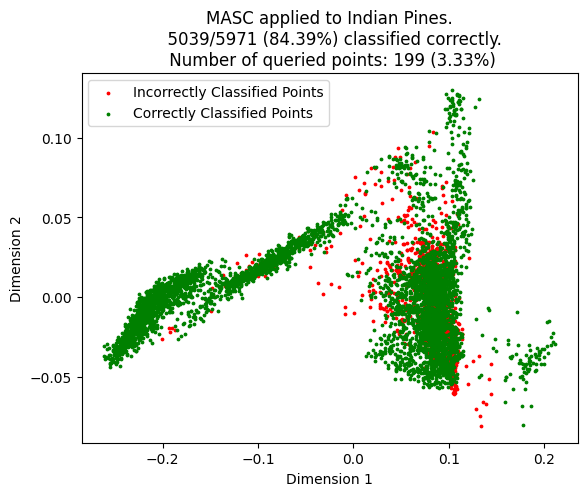

In [20]:
plt.scatter(plotdim1[np.where(truthcheck3==False)[0]],plotdim2[np.where(truthcheck3==False)[0]],s=3,color="r",label=f"Incorrectly Classified Points")
plt.scatter(plotdim1[np.where(truthcheck3)[0]],plotdim2[np.where(truthcheck3)[0]],color="g",s=3,label=f"Correctly Classified Points")
plt.title(f'MASC applied to Indian Pines.\n  {correctnum3}/{trainsize} ({100*correctnum3/trainsize:.2f}%) classified correctly.\n Number of queried points: {len(A)} ({100*(len(A)/trainsize):.2f}%)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()

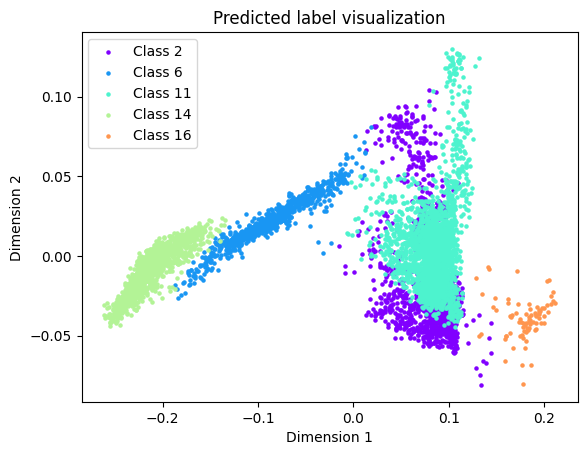

In [21]:
c=cm.rainbow(np.linspace(0,1,len(classes)+1))
color=0
for i in classes:
    plt.scatter(plotdim1[np.where(labels==i)[0]],plotdim2[np.where(labels==i)[0]],s=5,color=c[color],label=f"Class {i}")
    color+=1
plt.title('Predicted label visualization')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()